In [ ]:
import numpy as np

import seaborn as sns
import xarray as xr
import pandas as pd
from glaciation_time_estimator.auxiliary_func.config_reader import read_config
import cmcrameri.cm
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

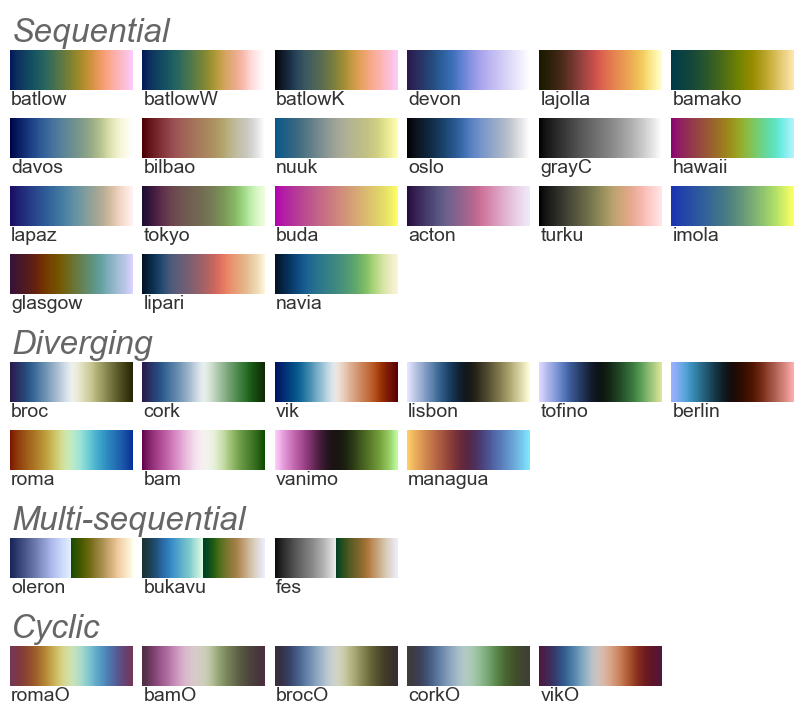

In [ ]:
%matplotlib inline
plt.rc('font',family='arial')
plt.rcParams.update({"font.size":5})
font= fm.FontProperties(family='arial')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
cmcrameri.cm.show_cmaps()
classifiacation_palette = cmcrameri.cm.actonS.colors[[i for i in range(10) if i != 1],:]

In [3]:
cmcrameri.cm.managua.colors[256//6,:]

array([0.7994  , 0.511449, 0.303754])

In [ ]:
# phase_pallette = ['#e41a1c', '#377eb8', "#4daf4a"]
phase_pallette = ['#e64b35','#4dbbd5']
config = read_config("/wolke_scratch/dnikolo/Glaciation_time_estimator/configs/2008_tracking/01_03.yaml")

In [5]:
tracking_data = xr.open_mfdataset('/wolke_scratch/dnikolo/Glac_visualization/20100501.0015_20100515.0000/pixel_path_tracking/20100501.0015_20100515.0000/cloud*.nc', combine='by_coords')

In [6]:
glac_df = pd.read_parquet('/wolke_scratch/dnikolo/Final_results/2010_glac_04.parquet') #pd.read_parquet('/wolke_scratch/dnikolo/Glac_visualization/Analysis_results/Agg_03_Glaciations.parquet')

In [7]:
glac_df=glac_df[~glac_df.is_large_pix_cloud]
glac_df = glac_df[(glac_df.avg_lat >30) | (glac_df.avg_lat<-30)]
lim_glac_df = glac_df[(glac_df["track_start_time"] > "2010-05-01 00:15:00") & (glac_df["track_start_time"] < "2010-05-15 00:00:00") & (glac_df["pole"]=="np") & (glac_df["min_temp"]==-30)]

In [8]:
# (lim_glac_df["avg_size[km]"]>50000).size
len(lim_glac_df[lim_glac_df["avg_size[km]"]>50000])

1

In [9]:
aux_file = xr.open_dataset("/wolke_scratch/dnikolo/CLAAS_Data/np/CM_SAF_CLAAS3_L2_AUX.nc",decode_times=False)
lat_mat = aux_file["lat"].values[0, :, :]
lon_mat = aux_file["lon"].values[0, :, :]

In [10]:
sample_glac = lim_glac_df[lim_glac_df["avg_size[km]"]>50000].sample(1)
def set_glac_properties(sample_glac):
    sample_glac["glaciation_start_time"] = sample_glac["track_start_time"]+ pd.Timedelta(minutes=15)*sample_glac["Glac_start_ind"]
    sample_glac["glaciation_end_time"] = sample_glac["track_start_time"]+ pd.Timedelta(minutes=15)*(sample_glac["Glac_peak_ind"]+1)
    sample_glac["track_end_time"] = sample_glac["track_start_time"]+ sample_glac["track_length"]
set_glac_properties(sample_glac)


In [11]:
# mpl.use("PDF")

In [12]:
glac_df.loc[56172].track_start_time

Timestamp('2010-05-13 07:30:00')

In [13]:
glac_df.loc[56172].avg_lat

68.97249593151317

In [14]:
glac_df.loc[56172].avg_lon

-11.287203774452351

In [15]:
a = np.array([[0.3, 0.5, 0.7, 0.2],[0.1, 0.2, 0.3, 0.2]])
(a*256).astype(int)

array([[ 76, 128, 179,  51],
       [ 25,  51,  76,  51]])

In [16]:
np.stack(cmcrameri.cm.managua.colors,axis=0)

array([[1.      , 0.81263 , 0.404239],
       [0.995163, 0.804546, 0.401552],
       [0.99024 , 0.796488, 0.398875],
       [0.985323, 0.788476, 0.396216],
       [0.980412, 0.780499, 0.39356 ],
       [0.975507, 0.772566, 0.39093 ],
       [0.970617, 0.764681, 0.3883  ],
       [0.965734, 0.756837, 0.385681],
       [0.960867, 0.749039, 0.383098],
       [0.956008, 0.741291, 0.380517],
       [0.951157, 0.733597, 0.377947],
       [0.946314, 0.725951, 0.375393],
       [0.941487, 0.718348, 0.37286 ],
       [0.936674, 0.710803, 0.370341],
       [0.931861, 0.703303, 0.367841],
       [0.927063, 0.695854, 0.365358],
       [0.922279, 0.688453, 0.362886],
       [0.917502, 0.681092, 0.360425],
       [0.912728, 0.673792, 0.358001],
       [0.907969, 0.66653 , 0.355581],
       [0.903213, 0.659321, 0.353163],
       [0.898462, 0.652158, 0.350776],
       [0.893721, 0.645033, 0.348388],
       [0.888989, 0.637961, 0.346011],
       [0.88426 , 0.630933, 0.343667],
       [0.879531, 0.62394

In [17]:
cmcrameri.cm.managua.colors[(a*255).astype(int),:]

array([[[0.627289, 0.319014, 0.242975],
        [0.343941, 0.159992, 0.281641],
        [0.31752 , 0.381947, 0.629693],
        [0.756471, 0.456632, 0.285607]],

       [[0.879531, 0.623946, 0.341336],
        [0.756471, 0.456632, 0.285607],
        [0.627289, 0.319014, 0.242975],
        [0.756471, 0.456632, 0.285607]]])

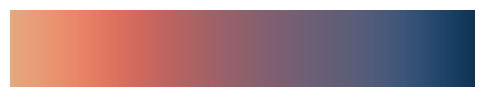

In [19]:
ncolors = len(cmcrameri.cm.managua.colors)
start_idx = int(0.15 * ncolors)
end_idx = int(0.85 * ncolors)
# middle_colors = cmcrameri.cm.managua.colors[start_idx:end_idx]
middle_colors = cmcrameri.cm.lipari.colors[int(0.1*255):int(0.8*255)][::-1]
cmap_middle = mpl.colors.LinearSegmentedColormap.from_list("lipari_custom", middle_colors)

# (Optional) Display the new colormap to verify
plt.figure(figsize=(6, 1))
plt.imshow([np.linspace(0, 1, 256)], aspect="auto", cmap=cmap_middle)
plt.axis("off")
plt.show()

In [22]:
def round_ind(arr):
    # 1. Determine the integer-degree targets present in your data
    start = int(np.ceil(arr.min()))   # e.g. ceil(-13.9895) = -13
    stop  = int(np.floor(arr.max()))  # e.g. floor(-12.1069) = -13
    # if your range spanned multiple integers, e.g. -14 to -12, you'd get [-13, -12]
    targets = np.arange(start, stop + 1)  # inclusive
    # print(start, stop, targets)

    # 2. Interpolate indices
    #    xp = lon values, fp = their indices
    indices = np.interp(targets, arr, np.arange(len(arr)))

    # 3. Report
    for t, idx in zip(targets, indices):
        # print(f"Longitude {t:+d}° at index ≃ {idx:.3f}")
        yield t,idx


In [52]:
mpl.rcParams.update({
    'text.color':            'black',
    'axes.labelcolor':       'black',
    'axes.edgecolor':        'black',
    'xtick.color':           'black',
    'ytick.color':           'black',
    'legend.edgecolor':      'black',
    'legend.facecolor':      'black',
    'grid.color':            'black',
})

plt.clf()
mpl.use('cairo')
plt.close('all')

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
from matplotlib import colors as mcolors
import matplotlib.gridspec as gridspec

# --- Assumes these are already in your notebook: ---
# cph_vals : numpy array of shape (n_time, H, W) with values in [0, 2]
# feat_vals: numpy array of shape (n_time, H, W) with track numbers
# cloud    : pandas Series (or dict-like) containing "tracknumber"
# ---------------------------------------------------------
cloud_id = 4
# for cloud_id in range(len(sample_glac)):
# cloud = sample_glac.iloc[cloud_id]
cloud = glac_df.loc[56172]
set_glac_properties(cloud)
# 2) Grab its start/end times
t0 = cloud.track_start_time
t1 = cloud.track_end_time 

# 4) Make sure your Dataset’s time coordinate is in datetime64:
#    (optional sanity check)
tracking_data['time'] = tracking_data.indexes['time']
# 5) Slice the Dataset in time and select the right track:
# sub = tracking_data.sel(
#     time=slice(t0, t1)
# )
sub = tracking_data.sel(
    time=slice(t0, t1)
)
# 6) Pull out the feature_number variable
feat_vals = sub['tracknumber'].values
cph_vals = sub["cph_filtered"].values
initial_mat = feat_vals[0]
end_mat = feat_vals[-1]
# print(len(initial_mat[initial_mat==(cloud["tracknumber"])]), cloud["avg_size[px]"], cloud["min_size[px]"], cloud["max_size[px]"])
size_change= len(initial_mat[initial_mat==(cloud["tracknumber"])])-len(end_mat[end_mat==(cloud["tracknumber"])])
t, x,y = np.where(feat_vals==cloud["tracknumber"])





# --- Assumes these are already in your notebook: ---
# cph_vals : numpy array of shape (n_time, H, W) with values in [0, 2]
# feat_vals: numpy array of shape (n_time, H, W) with track numbers
# cloud    : pandas Series (or dict-like) containing "tracknumber"
# ---------------------------------------------------------

track_id = cloud["tracknumber"]
n_frames, H, W = cph_vals.shape

# 1) Mask out everything except the target cloud:
masked_cph = np.full_like(cph_vals, np.nan, dtype=float)
for t in range(n_frames):
    mask = (feat_vals[t] == track_id)
    masked_cph[t] = np.where(mask, cph_vals[t], np.nan)

# 2) Find the bounding box (over all time steps) of non-NaN pixels:
ys, xs = np.where(np.any(~np.isnan(masked_cph), axis=0))
y_min, y_max = ys.min(), ys.max()
x_min, x_max = xs.min(), xs.max()

# 3) Expand the bounding box by a few pixels:
frame_width = 2
y0 = max(y_min - frame_width, 0)
y1 = min(y_max + 1 + frame_width, H)
x0 = max(x_min - frame_width, 0)
x1 = min(x_max + 1 + frame_width, W)

cloud_lon_array = aux_file.lon[0,y0*3,x0*3:x1*3].values[::3]
cloud_lat_array = aux_file.lat[0,y0*3:y1*3,x0*3].values[::3]
rounded_x_idx= np.array(list(round_ind(cloud_lon_array)))
rounded_y_idx= np.array(list(round_ind(cloud_lat_array[::-1])))
rounded_y_idx

cropped = cph_vals[:, y0:y1, x0:x1]
cropped_masked = masked_cph[:, y0:y1, x0:x1]
h_crop, w_crop = cropped.shape[1], cropped.shape[2]

# 4) Precompute RGB triplets for the palette
red_rgb   = np.array(mcolors.to_rgb('#e41a1c'))
blue_rgb  = np.array(mcolors.to_rgb('#377eb8'))
green_rgb = np.array(mcolors.to_rgb('#4daf4a'))
white_rgb = np.array([1.0, 1.0, 1.0])

# Function to build an RGB image for a given frame
def make_rgba_frame(frame_idx):
    frame_cph       = cropped[frame_idx]
    frame_cph_cloud = cropped_masked[frame_idx]
    rgb = np.ones((h_crop, w_crop, 3), dtype=float)  # start white

    # Cloud pixels with cph >= 1: interpolate from red to blue
    cloud_mask = ~np.isnan(frame_cph_cloud) & (frame_cph_cloud >= 1)
    if np.any(cloud_mask):
        vals = frame_cph_cloud[cloud_mask]
        t = (vals - 1.0) / 1.0  # normalize 1→0, 2→1
        n_colors = len(middle_colors)-1
        inter = middle_colors[(t*n_colors).astype(int),:]#np.outer(np.ones(t.shape))#np.outer(1 - t, red_rgb) + np.outer(t, blue_rgb)
        rgb[cloud_mask] = inter

    # Outside-cloud pixels (i.e., where frame_cph_cloud is NaN) with cph > 1: set green
    outside_mask = np.isnan(frame_cph_cloud) & (frame_cph > 1)
    rgb[outside_mask] = white_rgb#green_rgb
    # print(rgb.shape)v
    return rgb

# 5) Set up the figure with the first frame’s RGB
fig = plt.figure(figsize=(7.08, 9.322), constrained_layout=True)
gs = gridspec.GridSpec(10, 6,height_ratios=[0.1,1,0.05,0.1,1,0.05,0.1,1,0.05,0.5],width_ratios=[1,1,1,1,1,1],figure=fig)#,hspace=1.2, wspace=0.3)#,# Remove all borders and ticks.
ax7_0 = fig.add_subplot(gs[7, :3])
ax8_0 = fig.add_subplot(gs[8, :3])
gs7_0 = gs[7, :3].subgridspec(3,2,height_ratios=[1,1,1],width_ratios=[1,1])
initial_rgb = make_rgba_frame(0)
# im = ax7_0.imshow(initial_rgb, interpolation="none",
#             extent=(x0, x1, y1, y0))  # keep original coordinates
extent = (x0, x1, y1, y0)   # same as what you passed to imshow

# 2) keep track of the *boolean mask*, not the RGB
previous_mask = None



from matplotlib.lines import Line2D

# lock the zoom and show axes
ax7_0.set_autoscale_on(False)
ax7_0.axis('off')

# draw the first frame
# im = ax7_0.imshow(
#     make_rgba_frame(0),
#     interpolation='none',
#     extent=(x0, x1, y0, y1),
#     origin='lower'
# )

import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap, Normalize

# 1) Define the same colormap and norm you use in make_rgba_frame:
cmap = LinearSegmentedColormap.from_list('cph_rb',
                                         ['#e41a1c', '#377eb8'])
norm = Normalize(vmin=0.0, vmax=1.0)   # because you interpolate 1→0, 2→1

# 2) Create a ScalarMappable and register its “data range”:
sm = cm.ScalarMappable(cmap=cmap_middle, norm=norm)
sm.set_array([])    # only needed so colorbar can find the mappable’s range

# 3) After you do your imshow() but before the animation, add the colorbar:
cbar = fig.colorbar(sm, cax=ax8_0, location="bottom")
cbar.set_label('Pixel Ice Fraction',fontsize=6)# rotation=270, labelpad=15,
previous_mask = None

# 1) Create one Axes per frame in that subgridspec:
thumb_axes = []
for i in range(6):
    row, col = divmod(i, 2)   # 2 columns
    ax = fig.add_subplot(gs7_0[row, col])
    # ax.axis('off')
    if i //2 != 2:
        ax.tick_params(
            axis='both',        # both axes
            which='both',       # both major and minor ticks
            bottom=False,       # no ticks on the bottom
            labelbottom=False,  # no labels on the bottom
        )
    else:
        ax.set_xticks(rounded_x_idx[:,1][::2]+x0)
        ax.set_xticklabels(rounded_x_idx[:,0][::2].astype(int), fontsize=6)
        ax.set_xlabel('Longitude [°]', fontsize=6)
        ax.tick_params(axis='x', which='both', left=True,
                length=2,        # tick length in points
               width=0.5,       # (optional) tick thickness
               labelsize=5)     # you can also move fontsize here
    if i%2 ==1:
        
        ax.tick_params(
            axis='both',        # both axes
            which='both',       # both major and minor ticks
            left=False,         # no ticks on the left
            labelleft=False,    # no labels on the left
        )
    else:
        ax.set_yticks(y1-rounded_y_idx[:,1][::-1])
        ax.set_yticklabels(rounded_y_idx[:,0][::-1].astype(int), fontsize=6)
        ax.tick_params(axis='y', which='both', left=True,
                length=2,        # tick length in points
               width=0.5,       # (optional) tick thickness
               labelsize=5)     # you can also move fontsize here
        ax.set_ylabel('Latitude [°]', fontsize=6)
    thumb_axes.append(ax)
# legend_handle = Line2D(
#     [0], [0],
#     color='gray',
#     linestyle='--',
#     linewidth=1.5,
#     # label='Outline at previous timestep'
# )
# 2) Draw each initial thumbnail:
for i, ax in enumerate(thumb_axes):
    rgb = make_rgba_frame(i)
    ax.imshow(
        rgb,
        interpolation='none',
        extent=(x0, x1, y0, y1),
        origin='lower'
    )
    print(x0, x1, y0, y1)
    # if i==0:
    #     ax.legend(handles=[legend_handle], loc='upper left',fontsize=5)
    if previous_mask is not None:
        h, w = previous_mask.shape
        segs = []   # list of ((x1,x2), (y1,y2)) pairs

        for r in range(h):
            for c in range(w):
                if not previous_mask[r, c]:
                    continue

                # the pixel in data coords spans x: [x0+c, x0+c+1], y: [y0+r, y0+r+1]
                xL, xR = x0 + c,     x0 + c + 1
                yB, yT = y0 + r,     y0 + r + 1

                # if no neighbor to the left → draw left edge
                if c == 0         or not previous_mask[r, c-1]:
                    segs.append(((xL, xL), (yB, yT)))
                # right edge
                if c == w - 1     or not previous_mask[r, c+1]:
                    segs.append(((xR, xR), (yB, yT)))
                # bottom edge
                if r == 0         or not previous_mask[r-1, c]:
                    segs.append(((xL, xR), (yB, yB)))
                # top edge
                if r == h - 1     or not previous_mask[r+1, c]:
                    segs.append(((xL, xR), (yT, yT)))

        # 4) plot each segment as a Line2D
        for (xs, ys) in segs:
            ax.add_line(Line2D(xs, ys, color='black',alpha=0.7,
            linestyle='--', linewidth=0.5))#,label="Previous frame outline"))
            # 5) prepare for next frame:
    # ax.set_title(f"{(t0 + pd.Timedelta(minutes=15)*i).time().strftime('%-H:%M')}: Cloud Ice Fraction: {cloud['ice_frac_hist'][i]:.2f}",fontsize=5)
    ax.set_title(f"{(t0 + pd.Timedelta(minutes=15)*i).time().strftime('%-H:%M')}",fontsize=5)
    # ax.set_ylabel(f"")
    # print()
    previous_mask = ~np.isnan(cropped_masked[i])

/tmp/ipykernel_29406/2339170395.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_glac["glaciation_start_time"] = sample_glac["track_start_time"]+ pd.Timedelta(minutes=15)*sample_glac["Glac_start_ind"]
/tmp/ipykernel_29406/2339170395.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_glac["glaciation_end_time"] = sample_glac["track_start_time"]+ pd.Timedelta(minutes=15)*(sample_glac["Glac_peak_ind"]+1)
/tmp/ipykernel_29406/2339170395.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-do

462 493 11 20
462 493 11 20
462 493 11 20
462 493 11 20
462 493 11 20
462 493 11 20


In [54]:
appended_ice_fac_hist = [0.17]
appended_ice_fac_hist.extend(list(cloud['ice_frac_hist']))
appended_ice_fac_hist.append(0.47)

/tmp/ipykernel_29406/2136680845.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax7_1.set_xticklabels(tick_labels, rotation=45, ha='right',fontsize=5)


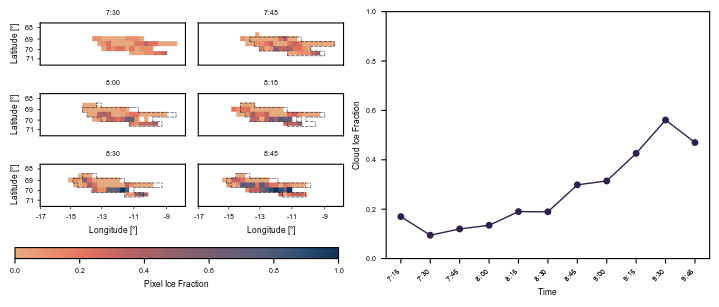

In [55]:
ax7_1 = fig.add_subplot(gs[7:9,3:])
tick_labels =[f"{(t0-pd.Timedelta(minutes=15)+pd.Timedelta(minutes=15)*i).time().strftime('%-H:%M')}" for i in range(len(appended_ice_fac_hist))]
ax7_1.plot( tick_labels, appended_ice_fac_hist,marker='o', label='North', linewidth=1,markersize=4,color=classifiacation_palette[0])
ax7_1.set_ylabel("Cloud Ice Fraction",fontsize=6)
ax7_1.set_xlabel("Time",fontsize=6)
ax7_1.set_ylim(0,1)
# ax7_1.ticks
ax7_1.set_xticklabels(tick_labels, rotation=45, ha='right',fontsize=5)
fig

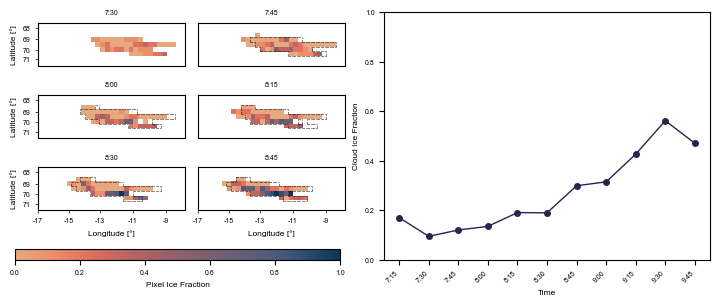

In [32]:
fig

In [56]:
fig.savefig(
    "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Methods_lower_panel_2.pdf",
    format="pdf",
    dpi=300
    # no bbox_inches argument at all
)

In [ ]:
# fig.savefig(
#     "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Methods_lower_panel_2.pdf",
#     format="pdf",
#     dpi=300
#     # no bbox_inches argument at all
# )
# fig.savefig(
#     "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Methods_lower_panel.eps",
#     format="eps",
#     dpi=300
#     # no bbox_inches argument at all
# )
# fig.savefig(
#     "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Methods_lower_panel.png",
#     format="png",
#     dpi=300
    # no bbox_inches argument at all
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [34]:
# 1) — globally turn all text white:
import matplotlib as mpl
mpl.rcParams.update({
    'text.color':            'white',
    'axes.labelcolor':       'white',
    'axes.edgecolor':        'white',
    'xtick.color':           'white',
    'ytick.color':           'white',
    'legend.edgecolor':      'white',
    'legend.facecolor':      'black',
    'grid.color':            'white',
})

# 2) — for any lines you add manually (e.g. those previous-mask outlines),
#     make sure to specify color='white':
from matplotlib.lines import Line2D
# example: ax.add_line(Line2D(xs, ys,
#                             color='white',
#                             linestyle='--',
#                             linewidth=0.5))

# 3) — if you have a Colorbar, recolor its ticks & border:
cbar = fig.colorbar(sm, cax=ax8_0, location="bottom")
cbar.outline.set_edgecolor('white')
cbar.ax.xaxis.set_tick_params(color='white', labelcolor='white')
cbar.set_label('Pixel Ice Fraction', fontsize=6, color='white')

/tmp/ipykernel_29406/2339170395.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_glac["glaciation_start_time"] = sample_glac["track_start_time"]+ pd.Timedelta(minutes=15)*sample_glac["Glac_start_ind"]
/tmp/ipykernel_29406/2339170395.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_glac["glaciation_end_time"] = sample_glac["track_start_time"]+ pd.Timedelta(minutes=15)*(sample_glac["Glac_peak_ind"]+1)
/tmp/ipykernel_29406/2339170395.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-do

462 493 11 20
462 493 11 20
462 493 11 20
462 493 11 20
462 493 11 20
462 493 11 20


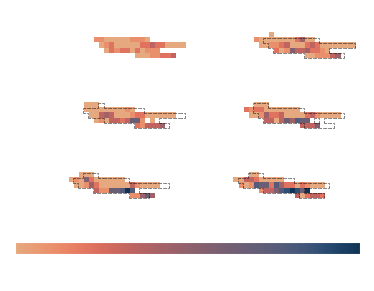

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
from matplotlib import colors as mcolors
import matplotlib.gridspec as gridspec

# --- Assumes these are already in your notebook: ---
# cph_vals : numpy array of shape (n_time, H, W) with values in [0, 2]
# feat_vals: numpy array of shape (n_time, H, W) with track numbers
# cloud    : pandas Series (or dict-like) containing "tracknumber"
# ---------------------------------------------------------
cloud_id = 4
# for cloud_id in range(len(sample_glac)):
# cloud = sample_glac.iloc[cloud_id]
cloud = glac_df.loc[56172]
set_glac_properties(cloud)
# 2) Grab its start/end times
t0 = cloud.track_start_time
t1 = cloud.track_end_time 

# 4) Make sure your Dataset’s time coordinate is in datetime64:
#    (optional sanity check)
tracking_data['time'] = tracking_data.indexes['time']
# 5) Slice the Dataset in time and select the right track:
# sub = tracking_data.sel(
#     time=slice(t0, t1)
# )
sub = tracking_data.sel(
    time=slice(t0, t1)
)
# 6) Pull out the feature_number variable
feat_vals = sub['tracknumber'].values
cph_vals = sub["cph_filtered"].values
initial_mat = feat_vals[0]
end_mat = feat_vals[-1]
# print(len(initial_mat[initial_mat==(cloud["tracknumber"])]), cloud["avg_size[px]"], cloud["min_size[px]"], cloud["max_size[px]"])
size_change= len(initial_mat[initial_mat==(cloud["tracknumber"])])-len(end_mat[end_mat==(cloud["tracknumber"])])
t, x,y = np.where(feat_vals==cloud["tracknumber"])





# --- Assumes these are already in your notebook: ---
# cph_vals : numpy array of shape (n_time, H, W) with values in [0, 2]
# feat_vals: numpy array of shape (n_time, H, W) with track numbers
# cloud    : pandas Series (or dict-like) containing "tracknumber"
# ---------------------------------------------------------

track_id = cloud["tracknumber"]
n_frames, H, W = cph_vals.shape

# 1) Mask out everything except the target cloud:
masked_cph = np.full_like(cph_vals, np.nan, dtype=float)
for t in range(n_frames):
    mask = (feat_vals[t] == track_id)
    masked_cph[t] = np.where(mask, cph_vals[t], np.nan)

# 2) Find the bounding box (over all time steps) of non-NaN pixels:
ys, xs = np.where(np.any(~np.isnan(masked_cph), axis=0))
y_min, y_max = ys.min(), ys.max()
x_min, x_max = xs.min(), xs.max()

# 3) Expand the bounding box by a few pixels:
frame_width = 2
y0 = max(y_min - frame_width, 0)
y1 = min(y_max + 1 + frame_width, H)
x0 = max(x_min - frame_width, 0)
x1 = min(x_max + 1 + frame_width, W)

cloud_lon_array = aux_file.lon[0,y0*3,x0*3:x1*3].values[::3]
cloud_lat_array = aux_file.lat[0,y0*3:y1*3,x0*3].values[::3]
rounded_x_idx= np.array(list(round_ind(cloud_lon_array)))
rounded_y_idx= np.array(list(round_ind(cloud_lat_array[::-1])))
rounded_y_idx

cropped = cph_vals[:, y0:y1, x0:x1]
cropped_masked = masked_cph[:, y0:y1, x0:x1]
h_crop, w_crop = cropped.shape[1], cropped.shape[2]

# 4) Precompute RGB triplets for the palette
red_rgb   = np.array(mcolors.to_rgb('#e41a1c'))
blue_rgb  = np.array(mcolors.to_rgb('#377eb8'))
green_rgb = np.array(mcolors.to_rgb('#4daf4a'))
white_rgb = np.array([1.0, 1.0, 1.0])

# Function to build an RGB image for a given frame
def make_rgba_frame(frame_idx):
    frame_cph       = cropped[frame_idx]
    frame_cph_cloud = cropped_masked[frame_idx]
    rgb = np.ones((h_crop, w_crop, 3), dtype=float)  # start white

    # Cloud pixels with cph >= 1: interpolate from red to blue
    cloud_mask = ~np.isnan(frame_cph_cloud) & (frame_cph_cloud >= 1)
    if np.any(cloud_mask):
        vals = frame_cph_cloud[cloud_mask]
        t = (vals - 1.0) / 1.0  # normalize 1→0, 2→1
        n_colors = len(middle_colors)-1
        inter = middle_colors[(t*n_colors).astype(int),:]#np.outer(np.ones(t.shape))#np.outer(1 - t, red_rgb) + np.outer(t, blue_rgb)
        rgb[cloud_mask] = inter

    # Outside-cloud pixels (i.e., where frame_cph_cloud is NaN) with cph > 1: set green
    outside_mask = np.isnan(frame_cph_cloud) & (frame_cph > 1)
    rgb[outside_mask] = white_rgb#green_rgb
    # print(rgb.shape)v
    return rgb

# 5) Set up the figure with the first frame’s RGB
fig = plt.figure(figsize=(7.08, 9.322), constrained_layout=True)
gs = gridspec.GridSpec(10, 6,height_ratios=[0.1,1,0.05,0.1,1,0.05,0.1,1,0.05,0.5],width_ratios=[1,1,1,1,1,1],figure=fig)#,hspace=1.2, wspace=0.3)#,# Remove all borders and ticks.
ax7_0 = fig.add_subplot(gs[7, :3])
ax8_0 = fig.add_subplot(gs[8, :3])
gs7_0 = gs[7, :3].subgridspec(3,2,height_ratios=[1,1,1],width_ratios=[1,1])
initial_rgb = make_rgba_frame(0)
# im = ax7_0.imshow(initial_rgb, interpolation="none",
#             extent=(x0, x1, y1, y0))  # keep original coordinates
extent = (x0, x1, y1, y0)   # same as what you passed to imshow

# 2) keep track of the *boolean mask*, not the RGB
previous_mask = None



from matplotlib.lines import Line2D

# lock the zoom and show axes
ax7_0.set_autoscale_on(False)
ax7_0.axis('off')

# draw the first frame
# im = ax7_0.imshow(
#     make_rgba_frame(0),
#     interpolation='none',
#     extent=(x0, x1, y0, y1),
#     origin='lower'
# )

import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap, Normalize

# 1) Define the same colormap and norm you use in make_rgba_frame:
cmap = LinearSegmentedColormap.from_list('cph_rb',
                                         ['#e41a1c', '#377eb8'])
norm = Normalize(vmin=0.0, vmax=1.0)   # because you interpolate 1→0, 2→1

# 2) Create a ScalarMappable and register its “data range”:
sm = cm.ScalarMappable(cmap=cmap_middle, norm=norm)
sm.set_array([])    # only needed so colorbar can find the mappable’s range

# 3) After you do your imshow() but before the animation, add the colorbar:
cbar = fig.colorbar(sm, cax=ax8_0, location="bottom")
cbar.set_label('Pixel Ice Fraction',fontsize=6)# rotation=270, labelpad=15,
previous_mask = None

# 1) Create one Axes per frame in that subgridspec:
thumb_axes = []
for i in range(6):
    row, col = divmod(i, 2)   # 2 columns
    ax = fig.add_subplot(gs7_0[row, col])
    # ax.axis('off')
    if i //2 != 2:
        ax.tick_params(
            axis='both',        # both axes
            which='both',       # both major and minor ticks
            bottom=False,       # no ticks on the bottom
            labelbottom=False,  # no labels on the bottom
        )
    else:
        ax.set_xticks(rounded_x_idx[:,1][::2]+x0)
        ax.set_xticklabels(rounded_x_idx[:,0][::2].astype(int), fontsize=6)
        ax.set_xlabel('Longitude [°]', fontsize=6)
        ax.tick_params(axis='x', which='both', left=True,
                length=2,        # tick length in points
               width=0.5,       # (optional) tick thickness
               labelsize=5)     # you can also move fontsize here
    if i%2 ==1:
        
        ax.tick_params(
            axis='both',        # both axes
            which='both',       # both major and minor ticks
            left=False,         # no ticks on the left
            labelleft=False,    # no labels on the left
        )
    else:
        ax.set_yticks(y1-rounded_y_idx[:,1][::-1])
        ax.set_yticklabels(rounded_y_idx[:,0][::-1].astype(int), fontsize=6)
        ax.tick_params(axis='y', which='both', left=True,
                length=2,        # tick length in points
               width=0.5,       # (optional) tick thickness
               labelsize=5)     # you can also move fontsize here
        ax.set_ylabel('Latitude [°]', fontsize=6)
    thumb_axes.append(ax)
# legend_handle = Line2D(
#     [0], [0],
#     color='gray',
#     linestyle='--',
#     linewidth=1.5,
#     # label='Outline at previous timestep'
# )
# 2) Draw each initial thumbnail:
for i, ax in enumerate(thumb_axes):
    rgb = make_rgba_frame(i)
    ax.imshow(
        rgb,
        interpolation='none',
        extent=(x0, x1, y0, y1),
        origin='lower'
    )
    print(x0, x1, y0, y1)
    # if i==0:
    #     ax.legend(handles=[legend_handle], loc='upper left',fontsize=5)
    if previous_mask is not None:
        h, w = previous_mask.shape
        segs = []   # list of ((x1,x2), (y1,y2)) pairs

        for r in range(h):
            for c in range(w):
                if not previous_mask[r, c]:
                    continue

                # the pixel in data coords spans x: [x0+c, x0+c+1], y: [y0+r, y0+r+1]
                xL, xR = x0 + c,     x0 + c + 1
                yB, yT = y0 + r,     y0 + r + 1

                # if no neighbor to the left → draw left edge
                if c == 0         or not previous_mask[r, c-1]:
                    segs.append(((xL, xL), (yB, yT)))
                # right edge
                if c == w - 1     or not previous_mask[r, c+1]:
                    segs.append(((xR, xR), (yB, yT)))
                # bottom edge
                if r == 0         or not previous_mask[r-1, c]:
                    segs.append(((xL, xR), (yB, yB)))
                # top edge
                if r == h - 1     or not previous_mask[r+1, c]:
                    segs.append(((xL, xR), (yT, yT)))

        # 4) plot each segment as a Line2D
        for (xs, ys) in segs:
            ax.add_line(Line2D(xs, ys, color='black',alpha=0.7,
            linestyle='--', linewidth=0.5))#,label="Previous frame outline"))
            # 5) prepare for next frame:
    # ax.set_title(f"{(t0 + pd.Timedelta(minutes=15)*i).time().strftime('%-H:%M')}: Cloud Ice Fraction: {cloud['ice_frac_hist'][i]:.2f}",fontsize=5)
    ax.set_title(f"{(t0 + pd.Timedelta(minutes=15)*i).time().strftime('%-H:%M')}",fontsize=5)
    # ax.set_ylabel(f"")
    # print()
    previous_mask = ~np.isnan(cropped_masked[i])

In [36]:
fig.savefig(
    "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/Methods_lower_panel_white_axes.png",
    format="png",
    dpi=300
    # no bbox_inches argument at all
)

In [27]:
plt.close('all')
def put_on_globe_filtered(arr_np,arr_sp):
    assert arr_np.shape==arr_sp.shape,"Two arrays of unequal size"
    assert len(arr_np.shape)==2,"The input arrays are not 2D"
    arr_shape =arr_np.shape
    full_size=3712
    start_idx_y=51
    end_idx_y = 3660
    if arr_shape[1]<2000:
        full_size//=3
        start_idx_y//=3
        end_idx_y //=3
    arr_shape=arr_np.shape
    full_image = np.full((full_size,full_size),np.nan)
    start_idx_x=int((full_image.shape[1]-arr_shape[1])/2)
    end_idx_x=start_idx_x+arr_shape[1]
    full_image[start_idx_y:start_idx_y+arr_shape[0],start_idx_x:end_idx_x]=arr_np
    full_image[end_idx_y-arr_shape[0]:end_idx_y,start_idx_x:end_idx_x]=arr_sp
    return full_image , (start_idx_x,end_idx_x),(start_idx_y,end_idx_y)
on_globe = put_on_globe_filtered(feat_vals[0],np.zeros(feat_vals[0].shape))[0]
# plt.imshow()
# plt.savefig("test.png")

In [28]:
xs,ys=np.where(on_globe==track_id)

In [29]:
np.max(xs),np.max(ys),np.min(xs),np.min(ys)

(33, 586, 30, 569)

In [30]:
fig.savefig(
    "/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_graphs/Publication_figures/test_methods.pdf",
    format="pdf",
    dpi=300
    # no bbox_inches argument at all
)

In [31]:
print(t0.time())

07:30:00
